# 05 - Revenue Prediction
Train a regression model to predict `sales` values ​​based on product, region, discount, and trend status.
Output: The regression model is saved to `encoders.pkl` (concatenated) or a separate file.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='darkgrid')
print('✅ Library is Ready')

✅ Library is Ready


## 1. Load Data & Feature Engineering

In [17]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
df['profit_margin'] = df['profit'] / df['sales']
df['revenue_per_unit'] = df['sales'] / df['quantity']
df['log_sales'] = np.log1p(df['sales'])

print(f'Data loaded: {df.shape}')
print(f'\nTarget (sales) stats:')
print(df['sales'].describe().round(0))

Data loaded: (5000, 20)

Target (sales) stats:
count      5000.0
mean     106733.0
std       85108.0
min         264.0
25%       39767.0
50%       83080.0
75%      156969.0
max      398485.0
Name: sales, dtype: float64


## 2. EDA Target Variable

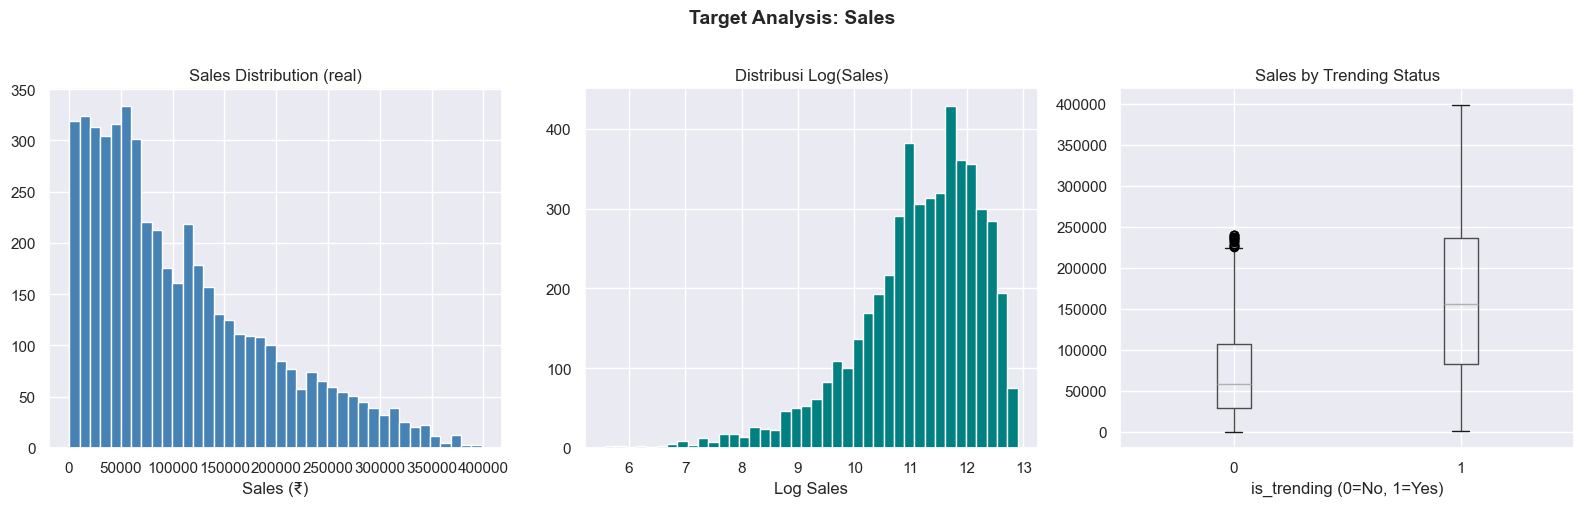

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi sales
axes[0].hist(df['sales'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (real)')
axes[0].set_xlabel('Sales (₹)')

# Log sales
axes[1].hist(df['log_sales'], bins=40, color='teal', edgecolor='white')
axes[1].set_title('Distribusi Log(Sales)')
axes[1].set_xlabel('Log Sales')

# Sales per is_trending
df.boxplot(column='sales', by='is_trending', ax=axes[2])
axes[2].set_title('Sales by Trending Status')
axes[2].set_xlabel('is_trending (0=No, 1=Yes)')
plt.suptitle('')

plt.suptitle('Target Analysis: Sales', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

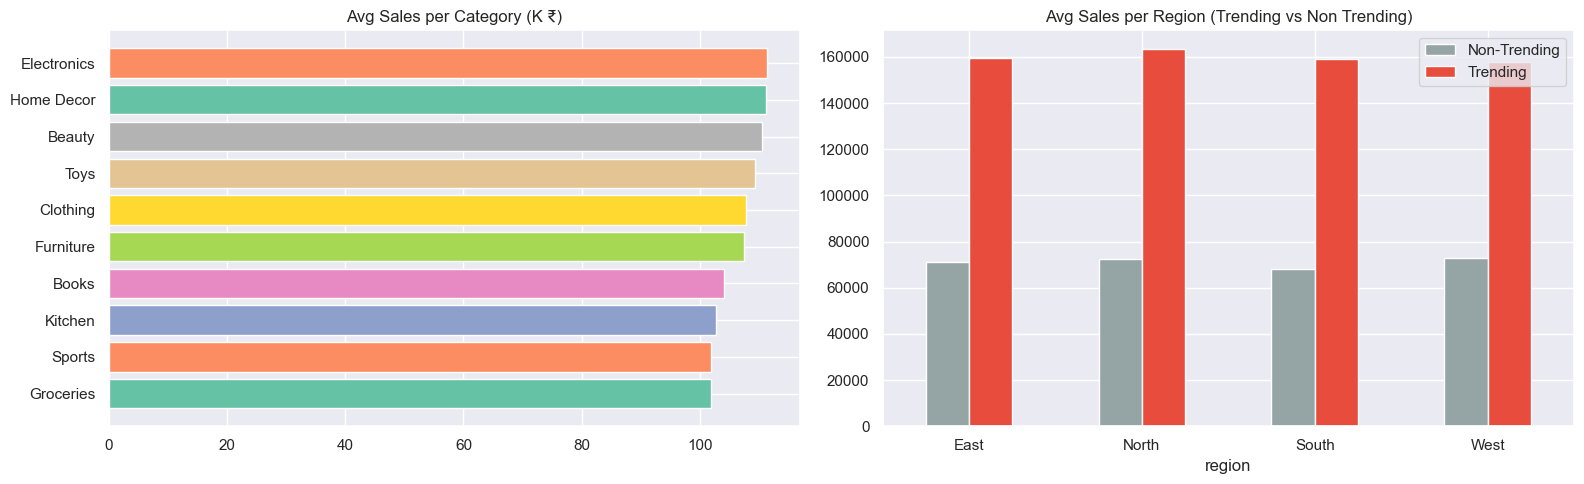

In [15]:
# Sales per category + region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_sales = df.groupby('category')['sales'].mean().sort_values(ascending=True)
axes[0].barh(cat_sales.index, cat_sales.values/1000, color=sns.color_palette('Set2'))
axes[0].set_title('Avg Sales per Category (K ₹)')

reg_sales = df.groupby(['region','is_trending'])['sales'].mean().unstack()
reg_sales.plot(kind='bar', ax=axes[1], color=['#95a5a6','#e74c3c'], rot=0)
axes[1].set_title('Avg Sales per Region (Trending vs Non Trending)')
axes[1].legend(['Non-Trending','Trending'])

plt.tight_layout()
plt.show()

## 3. Encoding Fitur

In [20]:
# Load encoder from notebook 02 if any
try:
    with open('../Notebooks/encoders.pkl', 'rb') as f:
        le_dict = pickle.load(f)
    print('✅ Encoder loaded from encoders.pkl')
except:
    le_dict = {}
    for col in ['region','city','category','sub_category','payment_mode']:
        le = LabelEncoder()
        le.fit(df[col])
        le_dict[col] = le
    print('✅ Encoder created new')

df_enc = df.copy()
for col in ['region','city','category','sub_category','payment_mode']:
    df_enc[col+'_enc'] = le_dict[col].transform(df[col])

FEATURES_REG = [
    'quantity', 'unit_price', 'discount', 'month', 'year',
    'is_trending', 'profit_margin', 'revenue_per_unit',
    'region_enc', 'city_enc', 'category_enc', 'sub_category_enc', 'payment_mode_enc'
]

X = df_enc[FEATURES_REG]
y = df_enc['log_sales']  # target = log(sales)
print(f'Shape: X={X.shape}')

✅ Encoder loaded from encoders.pkl
Shape: X=(5000, 13)


## 4. Split & Training Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

models = {
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression' : Ridge(alpha=1.0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)  
    y_true = np.expm1(y_test)
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results[name] = {'model': model, 'mae': mae, 'rmse': rmse, 'r2': r2}
    print(f'[{name}]  R²={r2:.4f}  MAE=₹ {mae:,.0f}  RMSE=₹ {rmse:,.0f}')

Train: 4,000 | Test: 1,000
[Random Forest]  R²=1.0000  MAE=₹ 258  RMSE=₹ 473
[Gradient Boosting]  R²=0.9994  MAE=₹ 1,477  RMSE=₹ 2,171
[Ridge Regression]  R²=0.7151  MAE=₹ 27,485  RMSE=₹ 46,534


## 5. Best Model Evaluation

🏆 Best Model: Random Forest
   R²   : 1.0000
   MAE  : ₹ 258
   RMSE : ₹ 473


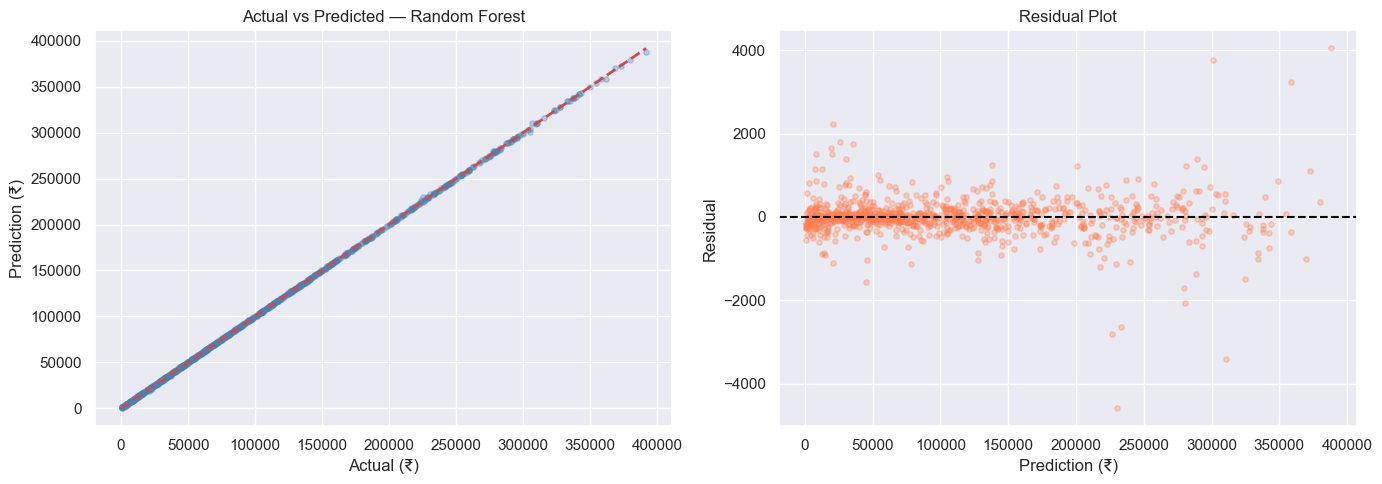

In [11]:
best_name = max(results, key=lambda x: results[x]['r2'])
best_model = results[best_name]['model']

y_pred_best = np.expm1(best_model.predict(X_test))
y_true_best = np.expm1(y_test)

print(f'🏆 Best Model: {best_name}')
print(f'   R²   : {results[best_name]["r2"]:.4f}')
print(f'   MAE  : ₹ {results[best_name]["mae"]:,.0f}')
print(f'   RMSE : ₹ {results[best_name]["rmse"]:,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_true_best, y_pred_best, alpha=0.3, color='steelblue', s=15)
max_val = max(y_true_best.max(), y_pred_best.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[0].set_xlabel('Actual (₹)')
axes[0].set_ylabel('Prediction (₹)')
axes[0].set_title(f'Actual vs Predicted — {best_name}')

# Residual plot
residuals = y_true_best.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, color='coral', s=15)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Prediction (₹)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

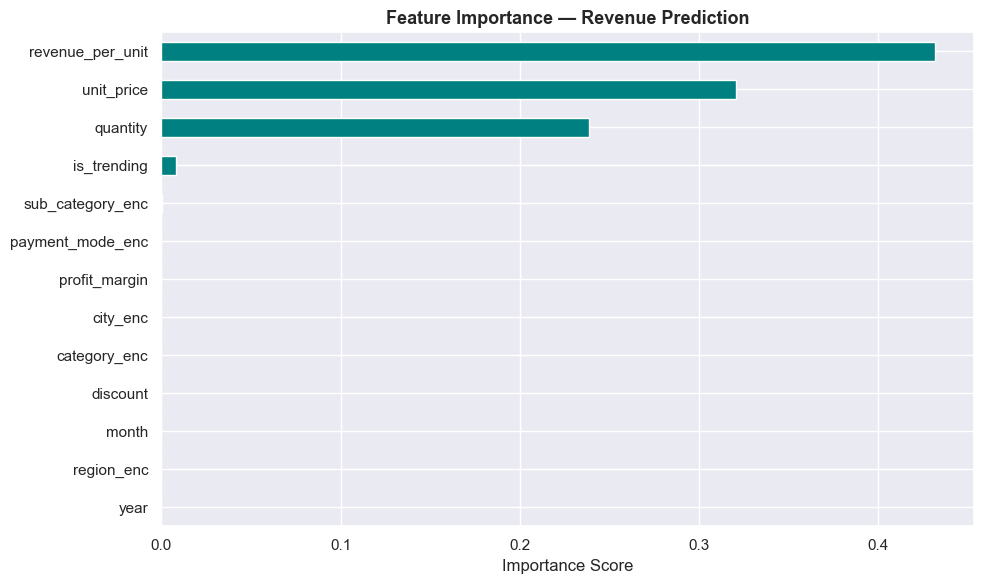

In [13]:
# Feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES_REG).sort_values()
    fig, ax = plt.subplots(figsize=(10, 6))
    fi.plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Feature Importance — Revenue Prediction', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

## 6. Prediction Simulation per Region & Category

In [22]:
def safe_enc(le, val):
    try: return int(le.transform([val])[0])
    except: return 0

summary = []
for region in df['region'].unique():
    for cat in df['category'].unique():
        for trending in [0, 1]:
            sub = df[(df['region']==region) & (df['category']==cat)]
            if len(sub) == 0: continue
            row = {
                'quantity'        : sub['quantity'].mean(),
                'unit_price'      : sub['unit_price'].mean(),
                'discount'        : sub['discount'].mean(),
                'month'           : 6, 'year': 2025,
                'is_trending'     : trending,
                'profit_margin'   : (sub['profit']/sub['sales']).mean(),
                'revenue_per_unit': (sub['sales']/sub['quantity']).mean(),
                'region_enc'      : safe_enc(le_dict['region'], region),
                'city_enc'        : 0,
                'category_enc'    : safe_enc(le_dict['category'], cat),
                'sub_category_enc': 0,
                'payment_mode_enc': 0
            }
            pred = np.expm1(best_model.predict(pd.DataFrame([row])[FEATURES_REG])[0])
            summary.append({'Region': region, 'Category': cat,
                            'Status': 'Trending' if trending else 'Non-Trending',
                            'Sales Prediction': pred})

df_sim = pd.DataFrame(summary)
top10 = df_sim[df_sim['Status']=='Trending'].sort_values('Sales Prediction', ascending=False).head(10)
print('🏆 TOP 10 Highest Revenue Opportunities (Trending Products):')
print(top10.to_string(index=False))

🏆 TOP 10 Highest Revenue Opportunities (Trending Products):
Region    Category   Status  Sales Prediction
 North    Clothing Trending     139681.581301
 North  Home Decor Trending     136311.319437
  West Electronics Trending     135907.363501
  East Electronics Trending     133160.575936
 South       Books Trending     132699.898525
  West   Furniture Trending     131897.591548
 North   Furniture Trending     131733.371638
 South      Beauty Trending     131502.428663
 North      Beauty Trending     130916.228292
 South      Sports Trending     128138.113429


## 7. Save the Revenue Prediction Model

In [23]:
# Update encoders.pkl dengan model regresi sekalian
try:
    with open('../Notebooks/encoders.pkl', 'rb') as f:
        existing = pickle.load(f)
except:
    existing = le_dict

# Simpan model regresi terpisah
with open('../Notebooks/encoders.pkl', 'wb') as f:
    pickle.dump({
        **existing,
        'reg_model'   : best_model,
        'features_reg': FEATURES_REG
    }, f)

print('✅ Regression model added to encoders.pkl')
print(f'   📦 Model: {best_name}')
print(f'   📌 R²: {results[best_name]["r2"]:.4f}')
print(f'   📌 MAE: Rp {results[best_name]["mae"]:,.0f}')
print()
print('✅ Income Prediction Notebook completed!')

✅ Regression model added to encoders.pkl
   📦 Model: Random Forest
   📌 R²: 1.0000
   📌 MAE: Rp 258

✅ Income Prediction Notebook completed!
